# Customer Churn Prediction: A Comparative Analysis of Machine Learning Models

This notebook presents a comprehensive analysis of various machine learning models for predicting customer churn. We will use a pre-processed and feature-engineered dataset to train, evaluate, and compare the performance of different classification algorithms.

### Objectives:
1.  **Load and Prepare Data**: Load the final dataset and prepare it for model training.
2.  **Train Multiple Models**: Train a selection of models, including a baseline, ensemble methods, and gradient boosting algorithms.
    - Logistic Regression
    - Random Forest
    - XGBoost
    - LightGBM
3.  **Evaluate Performance**: Assess each model using a suite of standard classification metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC).
4.  **Compare Models**: Directly compare the models to determine the most effective one for this specific churn prediction task.

## 1. Setup and Imports

First, we import the necessary libraries for data manipulation, modeling, and visualization.

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    roc_curve,
    precision_recall_curve,
    precision_score, 
    fbeta_score,
    classification_report
)

# Imbalanced-learn for handling imbalanced data
from imblearn.over_sampling import SMOTE

# Gradient Boosting models
import xgboost as xgb
import lightgbm as lgb

# General settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load and Prepare the Data

We'll load the `Churn_Modelling_Final.csv` dataset, which is the result of our previous data cleaning, feature engineering, and multicollinearity handling.

In [ ]:
# Load the dataset
try:
    df = pd.read_csv('../data/processed/customer_churn_data_final.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Churn_Modelling_Final.csv not found. Please run the data processing notebook first.")

# Display basic information about the dataset
if 'df' in locals():
    print(f"Dataset shape: {df.shape}")
    print("First 5 rows of the dataset:")
    display(df.head())

NameError: name 'pd' is not defined

### 2.1. Data Splitting and Scaling

We will split the data into features (X) and the target variable (y). Then, we'll create training and testing sets. Feature scaling is also applied, as it is crucial for models like Logistic Regression.

In [ ]:
# Define features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data into training and testing sets (80% train, 20% test)
# We use stratify=y to ensure the proportion of churned customers is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 8001 samples
Testing set size: 2001 samples


## 3. Model Training and Evaluation

To maintain clean and reusable code, we'll create a helper function to handle the training and evaluation process for each model.

In [ ]:
# Dictionary to store evaluation results for comparison
model_results = {}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Trains a model, evaluates its performance, and visualizes the confusion matrix.
    
    Args:
        model: The machine learning model instance.
        X_train, y_train: Training data and labels.
        X_test, y_test: Testing data and labels.
        model_name (str): The name of the model for reporting.
        
    Returns:
        A dictionary containing the model's performance metrics.
    """
    print(f'--- Training and Evaluating {model_name} ---')
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class
    
    # Calculate metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    # Print metrics
    for metric, value in metrics.items():
        print(f'{metric}: {value:.4f}')
    
    # Store results
    model_results[model_name] = metrics
    model_results[model_name]['Proba'] = y_proba
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return metrics

### 3.1. Logistic Regression (Baseline)

We start with Logistic Regression as a simple and interpretable baseline model. We use `class_weight='balanced'` to handle the imbalanced nature of the churn dataset.

--- Training and Evaluating Logistic Regression ---
Accuracy: 0.7251
Precision: 0.4025
Recall: 0.7181
F1-Score: 0.5158
ROC-AUC: 0.7941


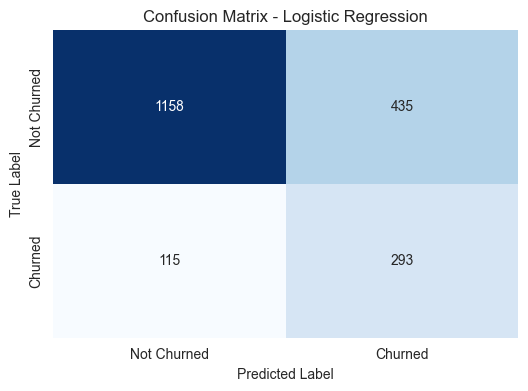

{'Accuracy': 0.7251374312843578,
 'Precision': 0.4024725274725275,
 'Recall': 0.7181372549019608,
 'F1-Score': 0.5158450704225352,
 'ROC-AUC': 0.79406225767143,
 'Proba': array([0.56002834, 0.41593613, 0.81939849, ..., 0.59780882, 0.47586515,
        0.44049082], shape=(2001,))}

In [ ]:
lr = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear')
evaluate_model(lr, X_train_scaled, y_train, X_test_scaled, y_test, 'Logistic Regression')

### 3.2. Random Forest

Next, we use a Random Forest, an ensemble model that often provides a significant performance boost over linear models. Tree-based models do not require feature scaling.

--- Training and Evaluating Random Forest ---
Accuracy: 0.8486
Precision: 0.6400
Recall: 0.5882
F1-Score: 0.6130
ROC-AUC: 0.8561


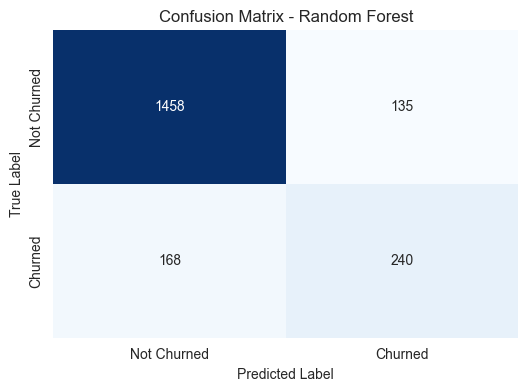

{'Accuracy': 0.848575712143928,
 'Precision': 0.64,
 'Recall': 0.5882352941176471,
 'F1-Score': 0.6130268199233716,
 'ROC-AUC': 0.8560845242051622,
 'Proba': array([0.60901422, 0.23914492, 0.70888537, ..., 0.49478096, 0.13372596,
        0.30942478], shape=(2001,))}

In [ ]:
rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=12, class_weight='balanced_subsample')
evaluate_model(rf, X_train, y_train, X_test, y_test, 'Random Forest')

### 3.3. XGBoost

XGBoost is a powerful and popular gradient boosting library. We'll calculate `scale_pos_weight` to handle class imbalance, which is a common practice for XGBoost.

--- Training and Evaluating XGBoost ---
Accuracy: 0.8101
Precision: 0.5255
Recall: 0.7083
F1-Score: 0.6033
ROC-AUC: 0.8527


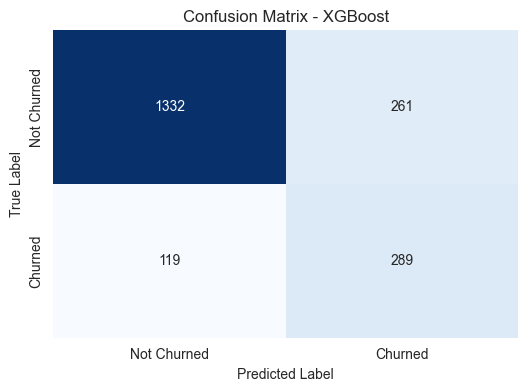

{'Accuracy': 0.8100949525237381,
 'Precision': 0.5254545454545455,
 'Recall': 0.7083333333333334,
 'F1-Score': 0.6033402922755741,
 'ROC-AUC': 0.8526549979690559,
 'Proba': array([0.73455393, 0.273175  , 0.84388137, ..., 0.54824567, 0.06327344,
        0.26300243], shape=(2001,), dtype=float32)}

In [ ]:
# Calculate scale_pos_weight for handling class imbalance in XGBoost
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_clf = xgb.XGBClassifier(
    random_state=42, 
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=5, 
    scale_pos_weight=scale_pos_weight, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
evaluate_model(xgb_clf, X_train, y_train, X_test, y_test, 'XGBoost')

### 3.4. LightGBM

LightGBM is another high-performance gradient boosting framework known for its speed and efficiency.

--- Training and Evaluating LightGBM ---
Accuracy: 0.8361
Precision: 0.5833
Recall: 0.6863
F1-Score: 0.6306
ROC-AUC: 0.8505


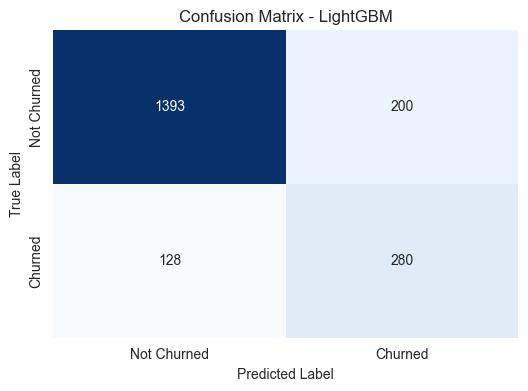

{'Accuracy': 0.8360819590204898,
 'Precision': 0.5833333333333334,
 'Recall': 0.6862745098039216,
 'F1-Score': 0.6306306306306306,
 'ROC-AUC': 0.8505332767130707,
 'Proba': array([0.56641662, 0.21915531, 0.80127938, ..., 0.63063723, 0.06371559,
        0.16200469], shape=(2001,))}

In [ ]:
lgbm = lgb.LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.1, class_weight='balanced')
evaluate_model(lgbm, X_train, y_train, X_test, y_test, 'LightGBM')

## 4. Model Comparison

Now we'll consolidate the results and visualize them to easily compare the performance of the different models.

Model Performance Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.848576,0.640000,0.588235,0.613027,0.856085
XGBoost,0.810095,0.525455,0.708333,0.603340,0.852655
LightGBM,0.836082,0.583333,0.686275,0.630631,0.850533
Logistic Regression,0.725137,0.402473,0.718137,0.515845,0.794062


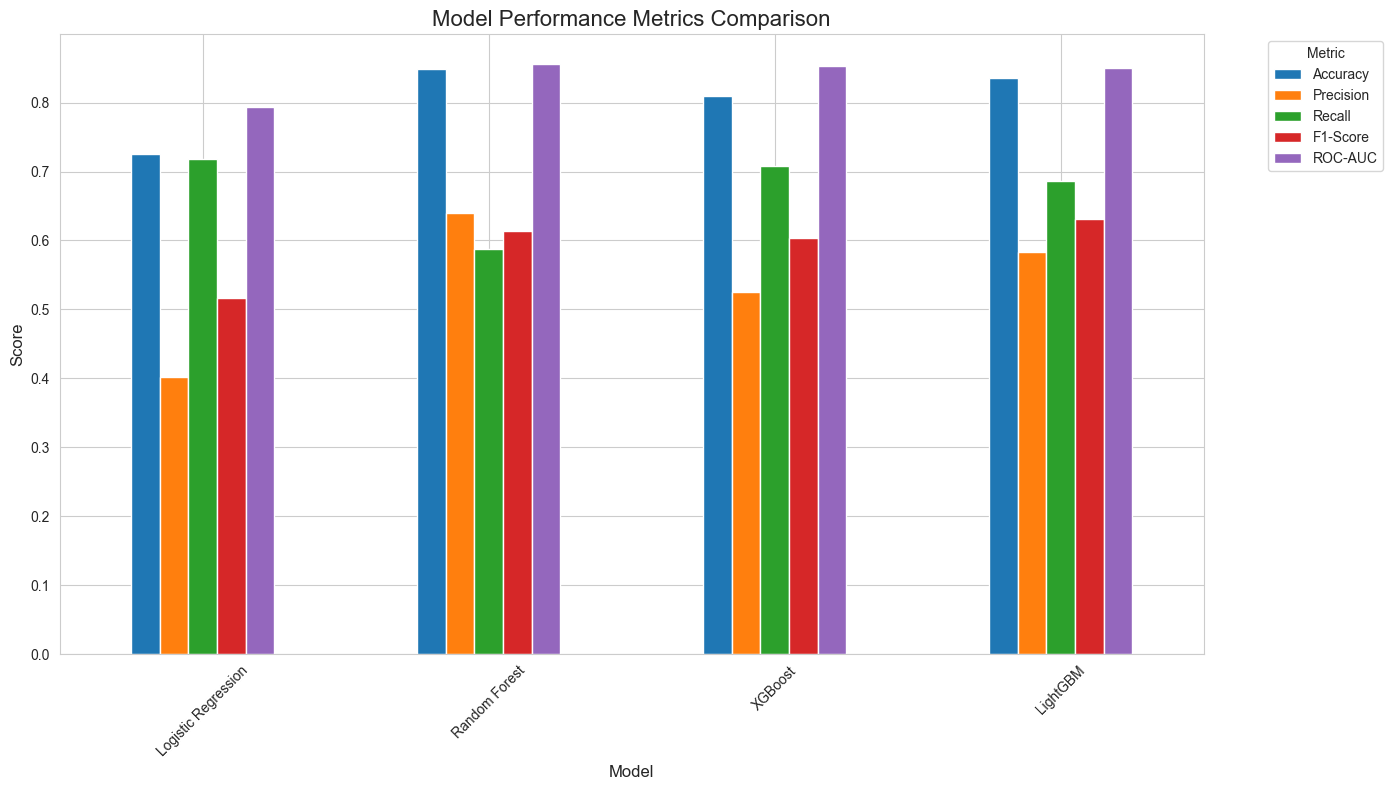

In [ ]:
# Create a DataFrame from the results dictionary for easy comparison
results_df = pd.DataFrame({model: {metric: value for metric, value in metrics.items() if metric != 'Proba'} 
                           for model, metrics in model_results.items()}).T

print("Model Performance Comparison:")
display(results_df.sort_values(by='ROC-AUC', ascending=False))

# Plotting the results
results_df.plot(kind='bar', figsize=(14, 8), rot=45)
plt.title('Model Performance Metrics Comparison', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### ROC Curve Comparison

The ROC curve is an excellent way to visualize the performance of binary classifiers. A model is better if its curve is closer to the top-left corner.

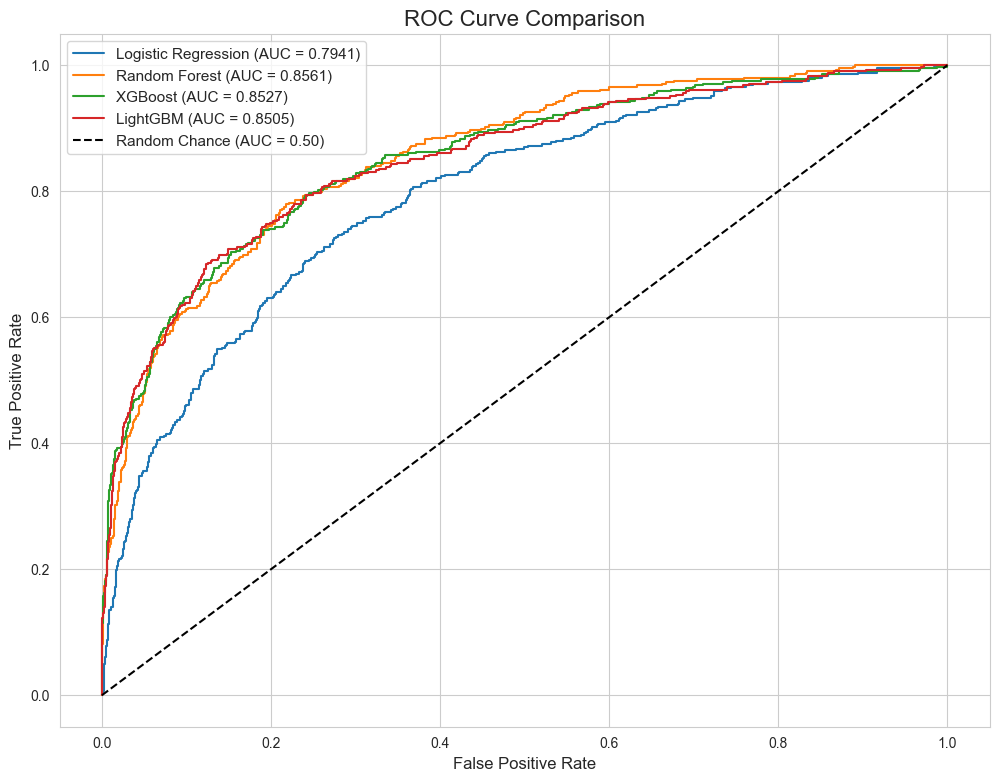

In [ ]:
plt.figure(figsize=(12, 9))

for model_name, metrics in model_results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['Proba'])
    auc = metrics['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')

# Plotting the random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=16)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

## 5. Conclusion

In this notebook, we trained and evaluated four different machine learning models for customer churn prediction. Based on the results, we can summarize the findings:

- **Performance**: The gradient boosting models (XGBoost and LightGBM) and Random Forest generally outperform the baseline Logistic Regression model across all metrics, especially in terms of ROC-AUC.
- **Best Model**: The choice of the "best" model depends on the specific business goal. If the primary goal is to maximize the identification of customers who will churn (high Recall), one model might be preferable.  For our case, righ recall is preferred as we dont want to miss on customers who can potentially churn.
- **Interpretability vs. Performance**: While models like XGBoost and LightGBM offer the best predictive power, Logistic Regression provides more interpretable coefficients, which can be valuable for understanding the drivers of churn.

This comparative analysis provides a solid foundation for selecting a model for deployment and for further fine-tuning.